In [5]:
import numpy as np               # numerical computing library
import matplotlib.pyplot as plt  # plotting library
import os                        # operating system interface

os.chdir(r'C:/Users/Giannis/.vscode/02_monte_carlo_simulation_toolkit')  # set working directory

Particles simulated:       10,000
Particles scattered < 10°: 9,768
Particles scattered > 90°: 19


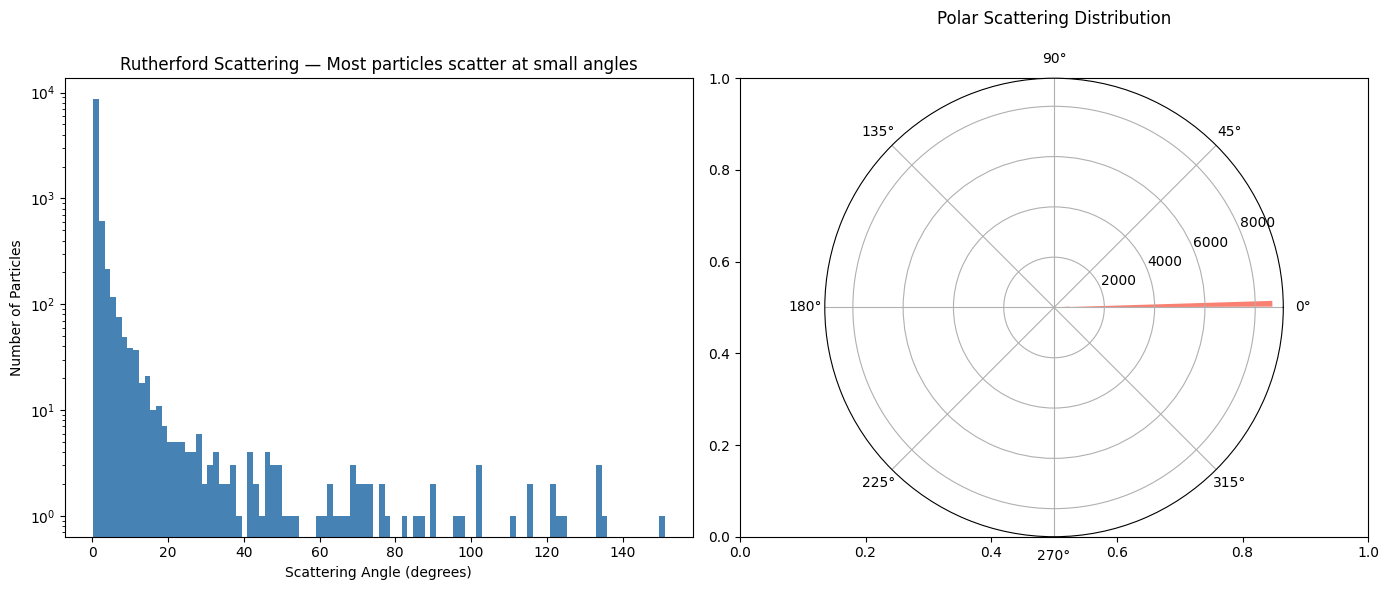

In [6]:
# === FORWARD PROBLEM ===
# Given known nucleus properties → predict scattering angle distribution

n_particles = 10_000  # number of alpha particles to simulate
a = 1.0               # normalized Coulomb parameter (depends on charges)

# impact parameter — how close each particle aims at the nucleus
# large b_max ensures most particles miss the nucleus (realistic beam)

b_max = 500.0
b = np.random.uniform(0.1, b_max, n_particles)  # random impact parameters

# Rutherford scattering formula — θ = 2·arctan(a/b)
# small b (close approach) → large deflection angle
# large b (far approach)  → small deflection angle

theta = 2 * np.arctan(a / b)

print(f'Particles simulated:       {n_particles:,}')
print(f'Particles scattered < 10°: {np.sum(np.degrees(theta) < 10):,}')  # most particles
print(f'Particles scattered > 90°: {np.sum(theta > np.pi/2):,}')         # rare direct hits

fig, axes = plt.subplots(1, 2, figsize=(14, 6))                          # two side by side plots

# left plot — histogram of scattering angles

axes[0].hist(np.degrees(theta), bins=100, color='steelblue', edgecolor='none')
axes[0].set_xlabel('Scattering Angle (degrees)')
axes[0].set_ylabel('Number of Particles')
axes[0].set_title('Rutherford Scattering — Most particles scatter at small angles')
axes[0].set_yscale('log')   # log scale reveals rare large-angle scattering events

# right plot — polar histogram showing angular distribution

ax_polar = fig.add_subplot(122, projection='polar')  # polar coordinate system
ax_polar.hist(theta, bins=100, color='salmon', edgecolor='none')
ax_polar.set_title('Polar Scattering Distribution', pad=20)

plt.tight_layout()
plt.savefig('results/02_particle_scattering.png', bbox_inches='tight')  # save to results
plt.show()

True Z:      47 (Silver)
Estimated Z: 47
Error:       0 units


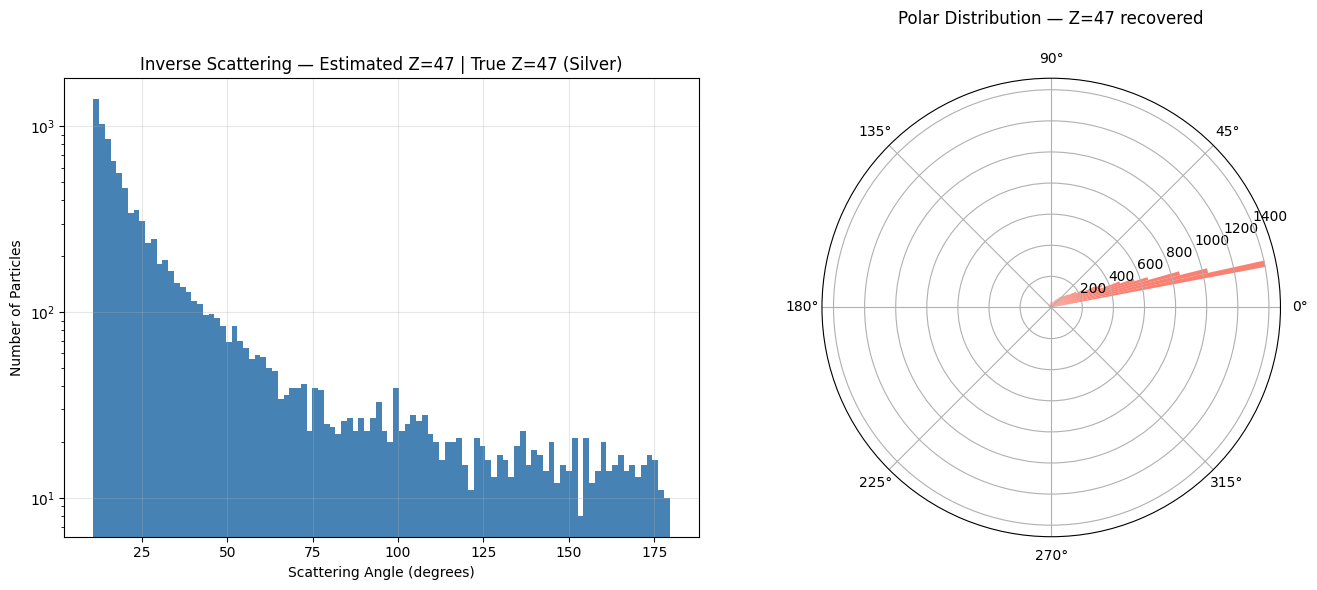

In [ ]:
# === INVERSE PROBLEM ===
# Given only scattering angle distribution → determine unknown material's Z
# Same mathematical principle as CT scanning and X-ray crystallography

# Step 1 — simulate mystery material with unknown Z

Z_true = 47             # Silver — we pretend we don't know this value
a_true = float(Z_true)  # Coulomb parameter proportional to atomic number Z
b_mystery = np.random.uniform(0.1, 500.0, n_particles)  # random impact parameters

# simulate scattering angles for mystery material using Rutherford formula

theta_mystery = 2 * np.arctan(a_true / b_mystery)

# Step 2 — back-calculate Z from observed scattering angles only
# rearranging Rutherford formula: a = b · tan(θ/2)
# median used instead of mean — robust against outliers from extreme angles

a_estimated = np.median(b_mystery * np.tan(theta_mystery / 2))
Z_estimated = round(a_estimated)  # round to nearest integer — Z must be whole number

print(f'True Z:      {Z_true} (Silver)')
print(f'Estimated Z: {Z_estimated}')
print(f'Error:       {abs(Z_true - Z_estimated)} units')

# Step 3 — visualize scattering distribution + polar plot

fig = plt.figure(figsize=(14, 6))  # create figure with two subplots

# left — histogram of scattering angles

ax1 = fig.add_subplot(121)  # 1 row, 2 cols, position 1
ax1.hist(np.degrees(theta_mystery), bins=100,
         color='steelblue', edgecolor='none')
ax1.set_xlabel('Scattering Angle (degrees)')
ax1.set_ylabel('Number of Particles')
ax1.set_title(f'Inverse Scattering — Estimated Z={Z_estimated} | True Z={Z_true} (Silver)')
ax1.set_yscale('log')       # log scale to show rare large-angle events
ax1.grid(True, alpha=0.3)   # light grid for readability

# right — polar histogram showing angular distribution

ax2 = fig.add_subplot(122, projection='polar')  # polar coordinate system
ax2.hist(theta_mystery, bins=100, color='salmon', edgecolor='none')
ax2.set_title(f'Polar Distribution — Z={Z_estimated} recovered', pad=20)

plt.tight_layout()
plt.savefig('results/02_inverse_scattering.png', bbox_inches='tight')  # save
plt.show()

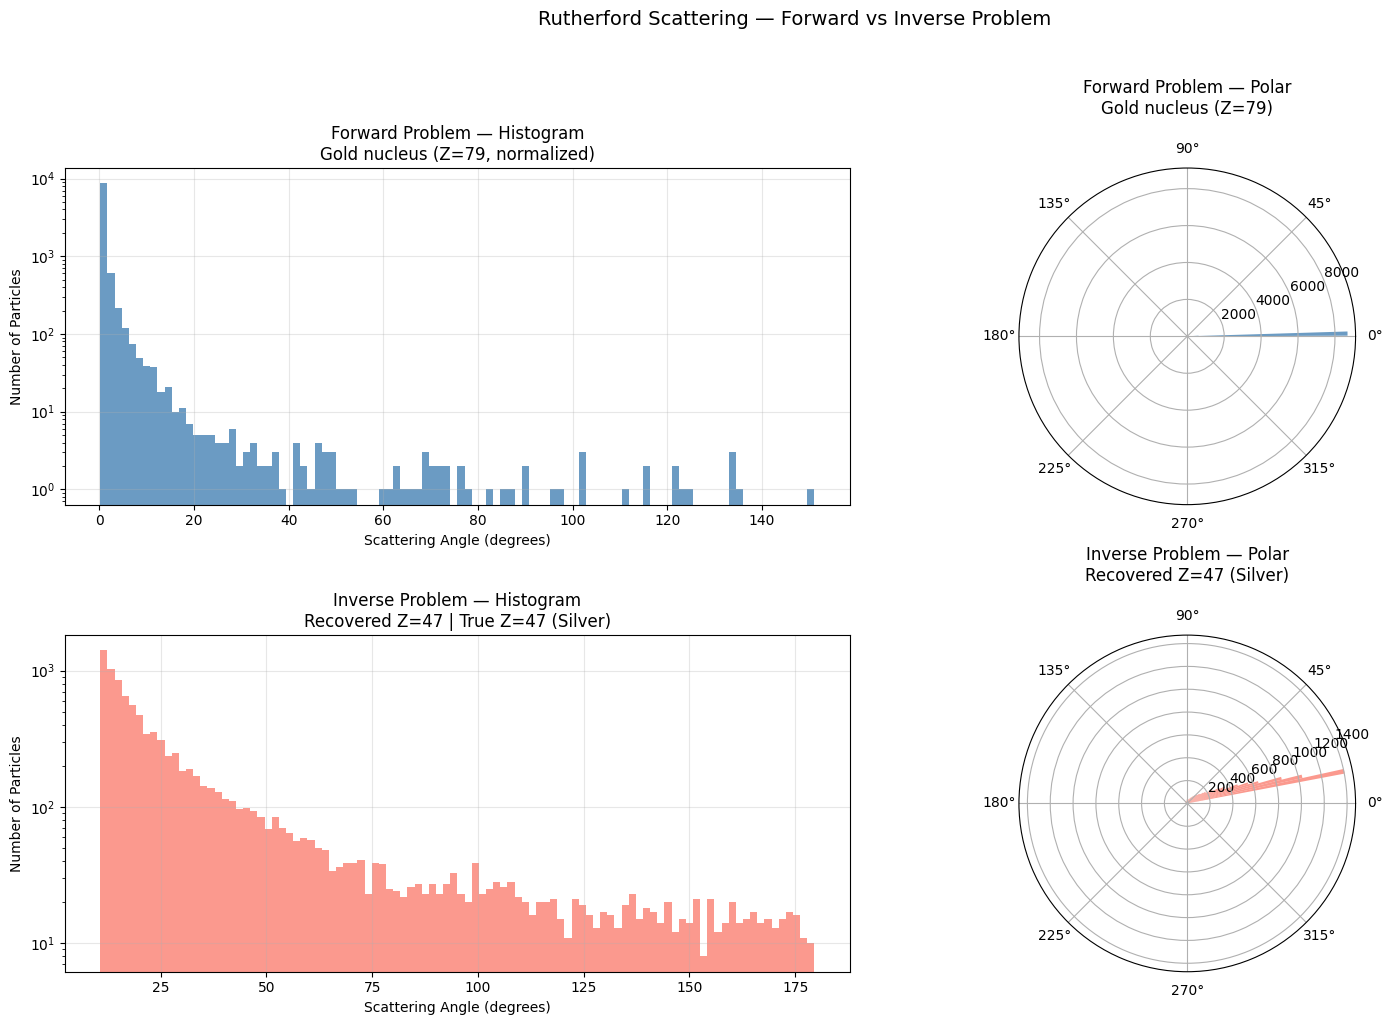

In [ ]:
# === COMPARISON PLOT — Forward vs Inverse ===
# 2x2 grid: histogram + polar for both forward and inverse problems

fig = plt.figure(figsize=(16, 10))  # larger figure for 2x2 grid

# --- Forward problem (top row) ---
# top left — forward histogram

ax1 = fig.add_subplot(221)  # 2 rows, 2 cols, position 1
ax1.hist(np.degrees(theta), bins=100,
         color='steelblue', edgecolor='none', alpha=0.8)
ax1.set_xlabel('Scattering Angle (degrees)')
ax1.set_ylabel('Number of Particles')
ax1.set_title('Forward Problem — Histogram\nGold nucleus (Z=79, normalized)')
ax1.set_yscale('log')        # log scale reveals rare large-angle events
ax1.grid(True, alpha=0.3)

# top right — forward polar

ax2 = fig.add_subplot(222, projection='polar')  # polar coordinate system
ax2.hist(theta, bins=100, color='steelblue', edgecolor='none', alpha=0.8)
ax2.set_title('Forward Problem — Polar\nGold nucleus (Z=79)', pad=20)

# --- Inverse problem (bottom row) ---

# bottom left — inverse histogram

ax3 = fig.add_subplot(223)  # 2 rows, 2 cols, position 3
ax3.hist(np.degrees(theta_mystery), bins=100,
         color='salmon', edgecolor='none', alpha=0.8)
ax3.set_xlabel('Scattering Angle (degrees)')
ax3.set_ylabel('Number of Particles')
ax3.set_title(f'Inverse Problem — Histogram\n'
              f'Recovered Z={Z_estimated} | True Z={Z_true} (Silver)')
ax3.set_yscale('log')        # log scale for consistency
ax3.grid(True, alpha=0.3)

# bottom right — inverse polar
ax4 = fig.add_subplot(224, projection='polar')  # polar coordinate system
ax4.hist(theta_mystery, bins=100, color='salmon', edgecolor='none', alpha=0.8)
ax4.set_title(f'Inverse Problem — Polar\n'
              f'Recovered Z={Z_estimated} (Silver)', pad=20)

plt.suptitle('Rutherford Scattering — Forward vs Inverse Problem',
             fontsize=14, y=1.02)  # overall title above all plots
plt.tight_layout()
plt.savefig('results/02_scattering_comparison.png',
            bbox_inches='tight')   # save 2x2 comparison plot
plt.show()